Name: Pathri Vidya Praveen  

Roll Number: CS24BTECH11047  

Collaborations with classmates: None  

Course: EE6380 Deep Learning  

Reference: Lecture Notes

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import v2

In [4]:
torch.manual_seed(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Exercise 1.1

In [6]:
# do not change the contents of this cell
training_file = np.load("training_data_p1.npz")
test_file = np.load("test_data_p1.npz")

training_x_p1 = training_file["x"]
training_y_p1 = training_file["y"]

test_x_p1 = test_file["x"]
test_y_p1 = test_file["y"]

print(training_x_p1.shape, training_y_p1.shape)
print(test_x_p1.shape, test_y_p1.shape)

(25,) (25,)
(35,) (35,)


In [7]:
def erm_p1(train_x,train_y):
    # put your code here
    # this function should return the thresholds a, b as per the ERM rule
    pos_x = train_x[train_y==1]
    if pos_x.size == 0:
      a=1.0
      b=0.0
    else:
      a = float(np.min(pos_x))
      b = float(np.max(pos_x))


    return(a,b)

a,b = erm_p1(training_x_p1,training_y_p1)
pred_y = np.zeros_like(test_x_p1)
pred_y[(test_x_p1>=a)&(test_x_p1<=b)] = 1
np.savez('prob1_predictions.npz',x=a,y=b)

# Add code here to compute and print the accuracy, precision, recall, F1 score
pred_y_int = pred_y.astype(int)
test_y_int = test_y_p1.astype(int)

tp = np.sum((pred_y_int == 1) & (test_y_int == 1))
tn = np.sum((pred_y_int == 0) & (test_y_int == 0))
fp = np.sum((pred_y_int == 1) & (test_y_int == 0))
fn = np.sum((pred_y_int == 0) & (test_y_int == 1))

accuracy = (tp+tn)/(tp+tn+fp+fn)

if (tp+fp) == 0:
  precision = 0
else:
  precision = tp/(tp+fp)

if (tp+fn) == 0:
  recall = 0
else:
  recall = tp/(tp+fn)

if precision+recall == 0:
  f1_score = 0
else:
  f1_score = 2*precision*recall/(precision+recall)

print(f"a = {a}, b = {b}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")


a = 0.4203546724414336, b = 0.4836375235621173
Accuracy: 0.8286
Precision: 1.0000
Recall: 0.3333
F1 Score: 0.5000


# Exercise 1.2

In [8]:
# do not change the contents of this cell
training_file = np.load("training_data_p2.npz")
test_file = np.load("test_data_p2.npz")

training_x_p2 = training_file["x"]
training_y_p2 = training_file["y"]

test_x_p2 = test_file["x"]
test_y_p2 = test_file["y"]

print(training_x_p2.shape, training_y_p2.shape)
print(test_x_p2.shape, test_y_p2.shape)

(20,) (20,)
(50,) (50,)


In [9]:
def erm_p2(train_x, train_y):
    # edit code below.
    # This function should return the coefficients of the predictor polynomial
    # Should be of the form [a0 a1 a2 ... am]
    train_x = np.asarray(train_x).reshape(-1)
    train_y = np.asarray(train_y).reshape(-1)
    # train test split implemented manually (Not sure if I can use sklearn as it is not given in the 1st cell)
    n = len(train_x)
    rng = np.random.default_rng(0)
    perm = rng.permutation(n)
    n_train = int(np.floor(0.8*n)) # 80% data in training set and 20% in validation set
    train_idx = perm[:n_train]
    val_idx = perm[n_train:]

    x_train, y_train = train_x[train_idx], train_y[train_idx]
    x_val, y_val = train_x[val_idx], train_y[val_idx]

    best_m = None
    best_val_mse = np.inf

    def mse(x,y,coeff):
      pred = np.polyval(np.flip(coeff),x)
      return np.mean((pred - y)**2)

    for m in range(1,11):
      coeff = np.polyfit(x_train,y_train,m)
      val_mse = mse(x_val,y_val,coeff)
      if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_m = m


    print(f"Selected model order is {best_m} and its validation MSE is {best_val_mse:.6f}")

    coeff_array = np.flip(np.polyfit(train_x,train_y,best_m))
    return(coeff_array)


coeff_array = erm_p2(training_x_p2,training_y_p2)
predictions = np.zeros_like(test_x_p2)
# complete the code below
predictions = np.polyval(np.flip(coeff_array),test_x_p2)
# print MSE
test_mse = np.mean((predictions - test_y_p2)**2)
print(f"Test MSE: {test_mse:.6f}")
# do not remove the following line
np.savez('prob2_predictions.npz',x=coeff_array)

Selected model order is 5 and its validation MSE is 0.658473
Test MSE: 0.097207


# Exercise 1.3

In [10]:
# do not edit this cell
training_data = datasets.FashionMNIST(root='../data',download=True,train=True,transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]))
test_data = datasets.FashionMNIST(root='../data',download=True,train=False,transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]))

100%|██████████| 26.4M/26.4M [00:00<00:00, 115MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.93MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 58.8MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 33.8MB/s]


In [11]:
x_train = training_data.data.float().div(255).flatten(1)
x_test = test_data.data.float().div(255).flatten(1)
y_train = training_data.targets
y_test = test_data.targets

In [12]:
d = 784
n = len(training_data)
batchsize = 64
epochs = 5
no_batches = n//batchsize

learningrate = 0.1

In [13]:
def activationfn(ubatch):
    # ubatch is batchsize x 10
    return( ubatch.exp()/ubatch.exp().sum(-1).unsqueeze(-1) )
def model(xbatch):
    # xbatch is of size batchsize x d
    return( activationfn( xbatch @ W + b ) )

def model_2nn(xbatch,W1,b1,W2,b2):
    # one hidden layer neural net
    z = xbatch @ W1 + b1
    a = torch.tanh(z)
    beliefs = activationfn( a @ W2 + b2 )
    return (beliefs, a)





In [14]:
def compute_loss(beliefs,ybatch):
    nb = ybatch.shape[0]
    return ( -torch.log(beliefs[torch.arange(nb),ybatch] + 1e-8).mean())

def compute_accuracy(xbatch,ybatch):
    with torch.no_grad():
      beliefs = model(xbatch)
      accuracy = (beliefs.argmax(-1) == ybatch).float().mean().item()



    return(accuracy)

def compute_accuracy_2nn(xbatch,ybatch,W1,b1,W2,b2):
    with torch.no_grad():
      beliefs, _ = model_2nn(xbatch,W1,b1,W2,b2)
      accuracy = (beliefs.argmax(-1) == ybatch).float().mean().item()



    return(accuracy)

In [15]:
W0 = torch.randn(d,10)/28
b0 = torch.randn(10)
h = 20
W1_0 = torch.randn(d,h)/28
b1_0 = torch.zeros(h)
W2_0 = torch.randn(h,10)/np.sqrt(h)
b2_0 = torch.zeros(10)

In [23]:
"""
Optimizer:
1 = SGD (random shuffling)
2 = Adagrad
3 = RMSprop
4 = Adam
5 = Polyak momentum
6 = Nesterov acceleration
"""
BETA_ADAGRAD = 0.99 # Ambiguous about what exactly is beta in Adagrad as per lecture notes... so I am not using it in the code anywhere...
BETA_RMS = 0.99
ALPHA_ADAM = 0.9
BETA_ADAM = 0.99
ALPHA_POLYAK = 0.95
ALPHA_NESTEROV = 0.95
epsilon = 1e-8

# Save the training loss and accuracies to these arrays
num_optimizers = 6
optim_labels = ['SGD','Adagrad','RMSprop','Adam','Polyak','Nesterov']
training_loss_perceptron = np.zeros([epochs,num_optimizers])
training_accuracy_perceptron = np.zeros([epochs,num_optimizers])
test_accuracy_perceptron = np.zeros([epochs,num_optimizers])
training_loss_2nn = np.zeros([epochs,num_optimizers])
training_accuracy_2nn = np.zeros([epochs,num_optimizers])
test_accuracy_2nn = np.zeros([epochs,num_optimizers])

for opt in range(num_optimizers):
  print('Perceptron | Optimizer: ', optim_labels[opt])
  W = W0.clone()
  b = b0.clone()
  mW = torch.zeros_like(W)
  vW = torch.zeros_like(W)
  mb = torch.zeros_like(b)
  vb = torch.zeros_like(b)
  t_step = 0

  for i in range(epochs):
      print('Epoch: ',i)
      randompermutation = torch.randperm(n)
      x_perm = x_train[randompermutation]
      y_perm = y_train[randompermutation]
      trainingloss = []

      for t in range(no_batches):
          xbatch = x_perm[t*batchsize:(t+1)*batchsize]
          ybatch = y_perm[t*batchsize:(t+1)*batchsize]

          beliefs = model(xbatch)
          loss = compute_loss(beliefs,ybatch)
          trainingloss.append(float(loss))

          nb = xbatch.shape[0]
          Y = torch.eye(10)[ybatch]
          dU = (beliefs - Y)/nb
          gW = xbatch.T @ dU
          gb = dU.sum(0)
          t_step += 1

          with torch.no_grad():
              if opt == 0:
                W -= learningrate * gW
                b -= learningrate * gb
              elif opt == 1:
                # Note: There is no beta in Adagrad so I am not using it here in update step
                vW = vW + gW**2
                vb = vb + gb**2
                W -= learningrate*gW/(vW.sqrt()+epsilon)
                b -= learningrate*gb/(vb.sqrt()+epsilon)
              elif opt == 2:
                vW = BETA_RMS*vW + (1-BETA_RMS)*gW**2
                vb = BETA_RMS*vb + (1-BETA_RMS)*gb**2
                W -= learningrate * gW / (vW.sqrt()+epsilon)
                b -= learningrate * gb / (vb.sqrt()+epsilon)
              elif opt == 3:
                mW = ALPHA_ADAM*mW + (1-ALPHA_ADAM)*gW
                mb = ALPHA_ADAM*mb + (1-ALPHA_ADAM)*gb
                vW = BETA_ADAM*vW + (1-BETA_ADAM)*gW**2
                vb = BETA_ADAM*vb + (1-BETA_ADAM)*gb**2
                mW_hat = mW/(1-ALPHA_ADAM**t_step)
                mb_hat = mb/(1-ALPHA_ADAM**t_step)
                vW_hat = vW/(1-BETA_ADAM**t_step)
                vb_hat = vb/(1-BETA_ADAM**t_step)
                W -= learningrate * mW_hat / (vW_hat.sqrt()+epsilon)
                b -= learningrate * mb_hat / (vb_hat.sqrt()+epsilon)
              elif opt == 4:
                mW = ALPHA_POLYAK*mW + gW
                mb = ALPHA_POLYAK*mb + gb
                W -= learningrate * mW
                b -= learningrate * mb
              elif opt == 5:
                W_look = W - learningrate * ALPHA_NESTEROV * mW
                b_look = b - learningrate * ALPHA_NESTEROV * mb
                beliefs_look = activationfn(xbatch @ W_look + b_look)
                dU_look = (beliefs_look - Y)/nb
                gW_look = xbatch.T @ dU_look
                gb_look = dU_look.sum(0)

                mW = ALPHA_NESTEROV*mW + gW_look
                mb = ALPHA_NESTEROV*mb + gb_look
                W -= learningrate * mW
                b -= learningrate * mb

      training_loss_perceptron[i,opt] = np.mean(trainingloss)
      training_accuracy_perceptron[i,opt] = compute_accuracy(x_train,y_train)
      test_accuracy_perceptron[i,opt] = compute_accuracy(x_test,y_test)


Perceptron | Optimizer:  SGD
Epoch:  0
Epoch:  1
Epoch:  2
Epoch:  3
Epoch:  4
Perceptron | Optimizer:  Adagrad
Epoch:  0
Epoch:  1
Epoch:  2
Epoch:  3
Epoch:  4
Perceptron | Optimizer:  RMSprop
Epoch:  0
Epoch:  1
Epoch:  2
Epoch:  3
Epoch:  4
Perceptron | Optimizer:  Adam
Epoch:  0
Epoch:  1
Epoch:  2
Epoch:  3
Epoch:  4
Perceptron | Optimizer:  Polyak
Epoch:  0
Epoch:  1
Epoch:  2
Epoch:  3
Epoch:  4
Perceptron | Optimizer:  Nesterov
Epoch:  0
Epoch:  1
Epoch:  2
Epoch:  3
Epoch:  4


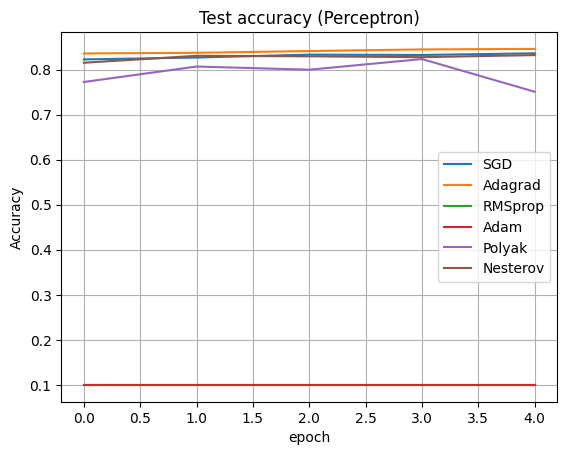

In [24]:
for i in range(num_optimizers):
    plt.plot(np.arange(epochs),test_accuracy_perceptron[:, i],label=optim_labels[i])

plt.title('Test accuracy (Perceptron)')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


In [25]:


for opt in range(num_optimizers):
  print('2NN | Optimizer: ', optim_labels[opt])
  W1 = W1_0.clone()
  b1 = b1_0.clone()
  W2 = W2_0.clone()
  b2 = b2_0.clone()
  mW1 = torch.zeros_like(W1)
  vW1 = torch.zeros_like(W1)
  mb1 = torch.zeros_like(b1)
  vb1 = torch.zeros_like(b1)
  mW2 = torch.zeros_like(W2)
  vW2 = torch.zeros_like(W2)
  mb2 = torch.zeros_like(b2)
  vb2 = torch.zeros_like(b2)
  t_step = 0

  for i in range(epochs):
      print('Epoch: ',i)
      randompermutation = torch.randperm(n)
      x_perm = x_train[randompermutation]
      y_perm = y_train[randompermutation]
      trainingloss = []

      for t in range(no_batches):
          xbatch = x_perm[t*batchsize:(t+1)*batchsize]
          ybatch = y_perm[t*batchsize:(t+1)*batchsize]

          beliefs, a = model_2nn(xbatch,W1,b1,W2,b2)
          loss = compute_loss(beliefs,ybatch)
          trainingloss.append(float(loss))

          nb = xbatch.shape[0]
          Y = torch.eye(10)[ybatch]
          dU = (beliefs - Y)/nb
          gW2 = a.T @ dU
          gb2 = dU.sum(0)
          dU.sum(0)
          dA = dU @ W2.T
          dZ = dA * (1 - a**2)
          gW1 = xbatch.T @ dZ
          gb1 = dZ.sum(0)

          t_step += 1

          with torch.no_grad():
              if opt == 0:
                W1 -= learningrate * gW1
                W2 -= learningrate * gW2
                b1 -= learningrate * gb1
                b2 -= learningrate * gb2
              elif opt == 1:
                # Note: There is no beta in Adagrad so I am not using it here in update step
                vW1 = vW1 + gW1**2
                vW2 = vW2 + gW2**2
                vb1 = vb1 + gb1**2
                vb2 = vb2 + gb2**2
                W1 -= learningrate*gW1/(vW1.sqrt()+epsilon)
                b1 -= learningrate*gb1/(vb1.sqrt()+epsilon)
                W2 -= learningrate*gW2/(vW2.sqrt()+epsilon)
                b2 -= learningrate*gb2/(vb2.sqrt()+epsilon)
              elif opt == 2:
                vW1 = BETA_RMS*vW1 + (1-BETA_RMS)*gW1**2
                vb1 = BETA_RMS*vb1 + (1-BETA_RMS)*gb1**2
                vW2 = BETA_RMS*vW2 + (1-BETA_RMS)*gW2**2
                vb2 = BETA_RMS*vb2 + (1-BETA_RMS)*gb2**2
                W1 -= learningrate * gW1 / (vW1.sqrt()+epsilon)
                b1 -= learningrate * gb1 / (vb1.sqrt()+epsilon)
                W2 -= learningrate * gW2 / (vW2.sqrt()+epsilon)
                b2 -= learningrate * gb2 / (vb2.sqrt()+epsilon)
              elif opt == 3:
                mW1 = ALPHA_ADAM*mW1 + (1-ALPHA_ADAM)*gW1
                mb1 = ALPHA_ADAM*mb1 + (1-ALPHA_ADAM)*gb1
                mW2 = ALPHA_ADAM*mW2 + (1-ALPHA_ADAM)*gW2
                mb2 = ALPHA_ADAM*mb2 + (1-ALPHA_ADAM)*gb2
                vW1 = BETA_ADAM*vW1 + (1-BETA_ADAM)*gW1**2
                vb1 = BETA_ADAM*vb1 + (1-BETA_ADAM)*gb1**2
                vW2 = BETA_ADAM*vW2 + (1-BETA_ADAM)*gW2**2
                vb2 = BETA_ADAM*vb2 + (1-BETA_ADAM)*gb2**2
                mW1_hat = mW1/(1-ALPHA_ADAM**t_step)
                mb1_hat = mb1/(1-ALPHA_ADAM**t_step)
                mW2_hat = mW2/(1-ALPHA_ADAM**t_step)
                mb2_hat = mb2/(1-ALPHA_ADAM**t_step)
                vW1_hat = vW1/(1-BETA_ADAM**t_step)
                vb1_hat = vb1/(1-BETA_ADAM**t_step)
                vW2_hat = vW2/(1-BETA_ADAM**t_step)
                vb2_hat = vb2/(1-BETA_ADAM**t_step)
                W1 -= learningrate * mW1_hat / (vW1_hat.sqrt()+epsilon)
                b1 -= learningrate * mb1_hat / (vb1_hat.sqrt()+epsilon)
                W2 -= learningrate * mW2_hat / (vW2_hat.sqrt()+epsilon)
                b2 -= learningrate * mb2_hat / (vb2_hat.sqrt()+epsilon)

              elif opt == 4:
                mW1 = ALPHA_POLYAK*mW1 + gW1
                mb1 = ALPHA_POLYAK*mb1 + gb1
                W1 -= learningrate * mW1
                b1 -= learningrate * mb1
                mW2 = ALPHA_POLYAK*mW2 + gW2
                mb2 = ALPHA_POLYAK*mb2 + gb2
                W2 -= learningrate * mW2
                b2 -= learningrate * mb2
              elif opt == 5:
                W1_look = W1 - learningrate * ALPHA_NESTEROV * mW1
                b1_look = b1 - learningrate * ALPHA_NESTEROV * mb1
                W2_look = W2 - learningrate * ALPHA_NESTEROV * mW2
                b2_look = b2 - learningrate * ALPHA_NESTEROV * mb2
                beliefs_look, a_look = model_2nn(xbatch,W1_look,b1_look,W2_look,b2_look)
                dU_look = (beliefs_look - Y)/nb
                gW2_look = a_look.T @ dU_look
                gb2_look = dU_look.sum(0)
                dA_look = dU_look @ W2_look.T
                dZ_look = dA_look * (1 - a_look**2)
                gW1_look = xbatch.T @ dZ_look
                gb1_look = dZ_look.sum(0)


                mW1 = ALPHA_NESTEROV*mW1 + gW1_look
                mb1 = ALPHA_NESTEROV*mb1 + gb1_look
                mW2 = ALPHA_NESTEROV*mW2 + gW2_look
                mb2 = ALPHA_NESTEROV*mb2 + gb2_look
                W1 -= learningrate * mW1
                b1 -= learningrate * mb1
                W2 -= learningrate * mW2
                b2 -= learningrate * mb2

      training_loss_2nn[i,opt] = np.mean(trainingloss)
      training_accuracy_2nn[i,opt] = compute_accuracy_2nn(x_train,y_train,W1,b1,W2,b2)
      test_accuracy_2nn[i,opt] = compute_accuracy_2nn(x_test,y_test,W1,b1,W2,b2)




2NN | Optimizer:  SGD
Epoch:  0
Epoch:  1
Epoch:  2
Epoch:  3
Epoch:  4
2NN | Optimizer:  Adagrad
Epoch:  0
Epoch:  1
Epoch:  2
Epoch:  3
Epoch:  4
2NN | Optimizer:  RMSprop
Epoch:  0
Epoch:  1
Epoch:  2
Epoch:  3
Epoch:  4
2NN | Optimizer:  Adam
Epoch:  0
Epoch:  1
Epoch:  2
Epoch:  3
Epoch:  4
2NN | Optimizer:  Polyak
Epoch:  0
Epoch:  1
Epoch:  2
Epoch:  3
Epoch:  4
2NN | Optimizer:  Nesterov
Epoch:  0
Epoch:  1
Epoch:  2
Epoch:  3
Epoch:  4


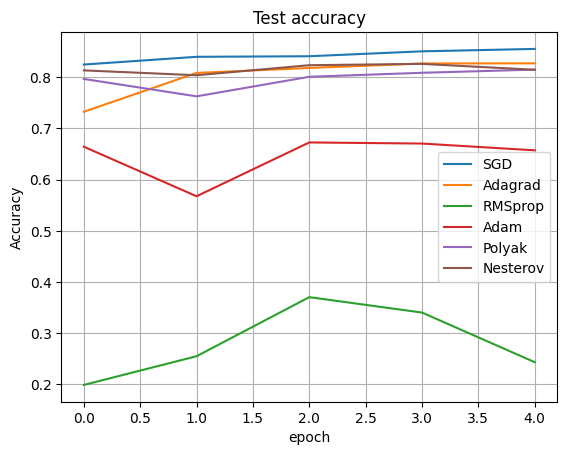

In [26]:
for i in range(num_optimizers):
    plt.plot(np.arange(epochs),test_accuracy_2nn[:,i].reshape(-1),label=optim_labels[i])
plt.title('Test accuracy')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


In [27]:
# Do not edit this cell
np.savez('prob3_trainingloss_perceptron.npz',training_loss_perceptron)
np.savez('prob3_trainingacc_perceptron.npz',training_accuracy_perceptron)
np.savez('prob3_testacc_perceptron.npz',test_accuracy_perceptron)
np.savez('prob3_trainingloss_2nn.npz',training_loss_2nn)
np.savez('prob3_trainingacc_2nn.npz',training_accuracy_2nn)
np.savez('prob3_testacc_2nn.npz',test_accuracy_2nn)

# Exercise 1.4

True gradient at [1,1,1]:  [ 1.54030231  2.54030231 -2.        ]


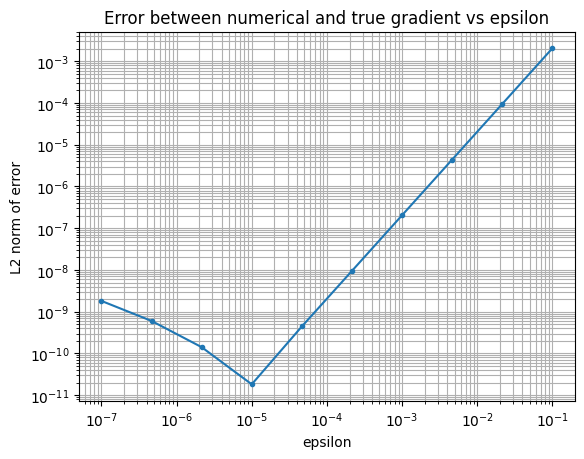

In [22]:
# Insert code here
def f(x):
  x1,x2,x3 = x
  return np.sin(x1*x2) + np.exp(x1-x3) + x2**2 - x3

def true_gradient(x):
  x1,x2,x3 = x
  df_dx1 = np.cos(x1*x2)*x2 + np.exp(x1-x3)
  df_dx2 = np.cos(x1*x2)*x1 + 2*x2
  df_dx3 = -np.exp(x1-x3) -1
  return np.array([df_dx1,df_dx2,df_dx3])

def numerical_gradient(f,x,epsilon):
  grad = np.zeros_like(x)
  for i in range(len(x)):
    x_plus = x.copy()
    x_minus = x.copy()
    x_plus[i] += epsilon
    x_minus[i] -= epsilon
    grad[i] = (f(x_plus) - f(x_minus))/(2*epsilon)

  return grad

x = np.array([1.0,1.0,1.0])
grad_true = true_gradient(x)
print('True gradient at [1,1,1]: ',grad_true)
epsilons = np.logspace(-7,-1,10)
errors = np.array([np.linalg.norm(numerical_gradient(f,x,epsilon) - grad_true) for epsilon in epsilons])

plt.figure()
plt.loglog(epsilons,errors,marker='o',markersize=3)
plt.xlabel('epsilon')
plt.ylabel('L2 norm of error')
plt.title('Error between numerical and true gradient vs epsilon')
plt.grid(True,which='both')
plt.show()
